# Car Price Prediction Model

Dataset:  https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?utm_source=chatgpt.com


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd


data = pd.read_csv("/content/sample_data/car data.csv")

print("Shape:", data.shape)
print(data.head())

Shape: (301, 9)
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [ ]:
print("Original Shape:", data.shape)
data = data.head(50)

print("New Shape:", data.shape)
print(data.head())

Original Shape: (301, 9)
New Shape: (50, 9)
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [ ]:
# Check missing values
print(data.isnull().sum())

# Select useful columns
features = ['Year', 'Selling_Price', 'Kms_Driven', 'Owner']
target = 'Present_Price'

X = data[features]
y = data[target]

print(X.head())
print(y.head())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
   Year  Selling_Price  Kms_Driven  Owner
0  2014           3.35       27000      0
1  2013           4.75       43000      0
2  2017           7.25        6900      0
3  2011           2.85        5200      0
4  2014           4.60       42450      0
0    5.59
1    9.54
2    9.85
3    4.15
4    6.87
Name: Present_Price, dtype: float64


In [ ]:

numeric_data = data.select_dtypes(include=[np.number])

print("Numeric Columns:")
print(numeric_data.columns)
print(numeric_data.shape)

Numeric Columns:
Index(['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner'], dtype='object')
(50, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.18359702 -0.57905569 -0.53936893  0.        ]
 [-0.12239801  0.04215348  0.18827642  0.        ]
 [ 1.10158211  1.15145558 -1.45347341  0.        ]
 [-0.73438807 -0.80091611 -1.53078572  0.        ]
 [ 0.18359702 -0.02440465  0.16326361  0.        ]]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40, 4)
(10, 4)


In [ ]:
features = ['Year', 'Selling_Price', 'Kms_Driven', 'Owner']
target = 'Present_Price'

X = data[features].values
y = data[target].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print(X[:10])
print(y[:10])

Shape of X: (50, 4)
Shape of y: (50,)
[[2.0140e+03 3.3500e+00 2.7000e+04 0.0000e+00]
 [2.0130e+03 4.7500e+00 4.3000e+04 0.0000e+00]
 [2.0170e+03 7.2500e+00 6.9000e+03 0.0000e+00]
 [2.0110e+03 2.8500e+00 5.2000e+03 0.0000e+00]
 [2.0140e+03 4.6000e+00 4.2450e+04 0.0000e+00]
 [2.0180e+03 9.2500e+00 2.0710e+03 0.0000e+00]
 [2.0150e+03 6.7500e+00 1.8796e+04 0.0000e+00]
 [2.0150e+03 6.5000e+00 3.3429e+04 0.0000e+00]
 [2.0160e+03 8.7500e+00 2.0273e+04 0.0000e+00]
 [2.0150e+03 7.4500e+00 4.2367e+04 0.0000e+00]]
[5.59 9.54 9.85 4.15 6.87 9.83 8.12 8.61 8.89 8.92]


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Weights: [-0.68681556  2.70036486  0.29006484  0.        ]
Bias: 6.987810530112996


In [ ]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[ 8.2133184   6.5970575   5.58475946  9.95586525 10.20445557  7.85214106
  6.68151131  5.26037258  7.21703093  5.33401445]


In [ ]:

predicted_price = model.predict(X_test)
#y' = XW+b
print("Predicted Price:", predicted_price)

Predicted Price: [ 8.2133184   6.5970575   5.58475946  9.95586525 10.20445557  7.85214106
  6.68151131  5.26037258  7.21703093  5.33401445]


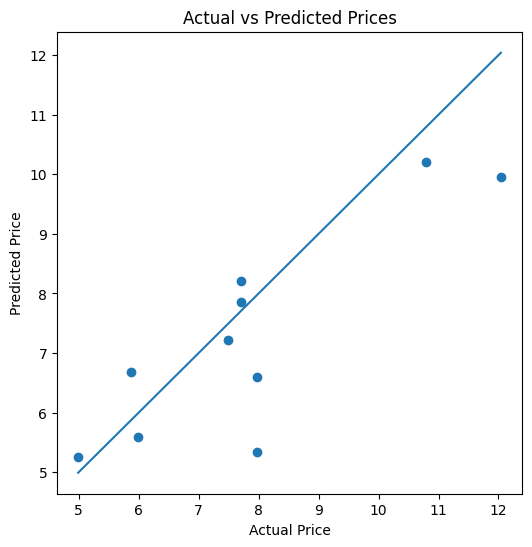

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

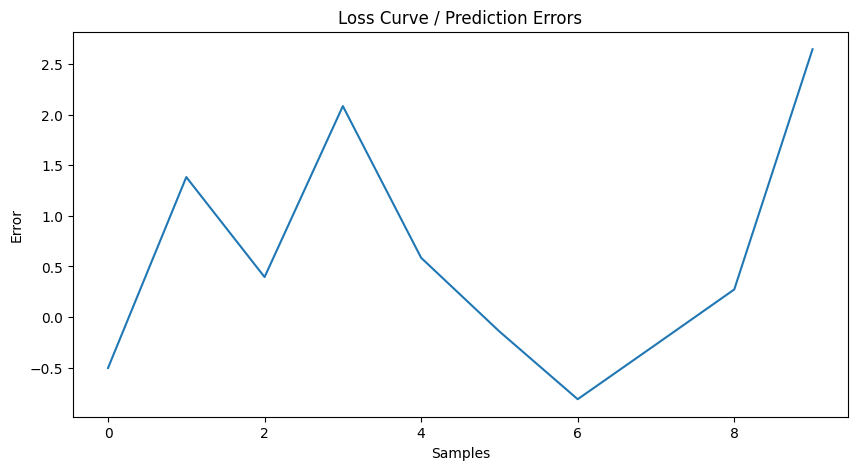

In [21]:
# Loss Curve / Error Curve
errors = y_test - y_pred # Calculate the prediction errors

plt.figure(figsize=(10,5))
plt.plot(errors.values)

plt.title("Loss Curve / Prediction Errors")
plt.xlabel("Samples")
plt.ylabel("Error")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 0.9094160189817897
MSE: 1.4836162061044933
R2 Score: 0.6467499718792397


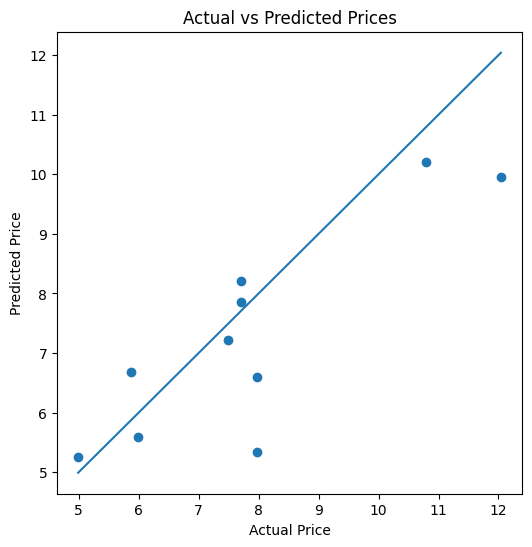

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()